In [1]:
import gymnasium as gym
import numpy as np

from q_learning import EpsilonGreedy, Qlearning
from quantile_regression import QuantileRegression
from dist_run import Params, run_env, save_experiment, load_experiment
from envs.register import register_envs

register_envs()

params = Params(
    model_name="Simple-v1",
    total_episodes=100_000,
    learning_rate=1.0,
    gamma=1.0,
    epsilon=1.0,
    seed=123,
    n_runs=1,
    action_size=None,
    state_size=None,
    n_quantiles=32,
    use_lr_decay=True,
    save_skip=1_000,
    huber_k=1.0,
)
rng = np.random.default_rng(params.seed)

In [6]:
env = gym.make(params.model_name)
params = params._replace(action_size=int(env.action_space.n))
params = params._replace(state_size=int(env.observation_space.n))
env.action_space.seed(params.seed)

learner = QuantileRegression(params)
explorer = EpsilonGreedy(params.epsilon, rng)
tables = run_env(env, learner, explorer, params)

save_experiment(tables, params)

tables = tables.mean(0)
qtables = tables.mean(-1) if params.n_quantiles > 1 else tables[-1]
qtable = qtables[-1]

Run 0/1 - Episodes: 100%|██████████| 100000/100000 [00:03<00:00, 28622.91it/s]


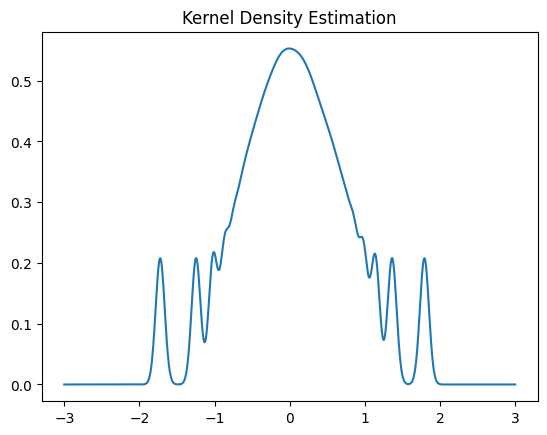

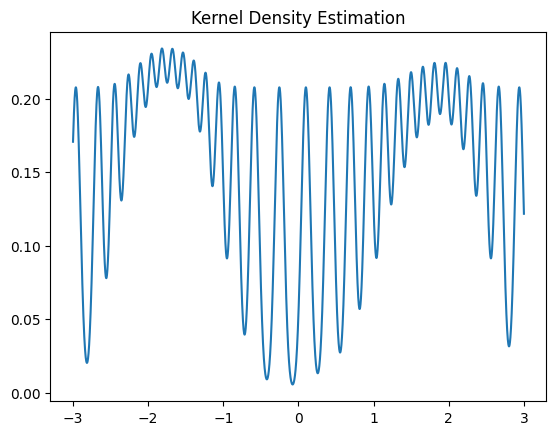

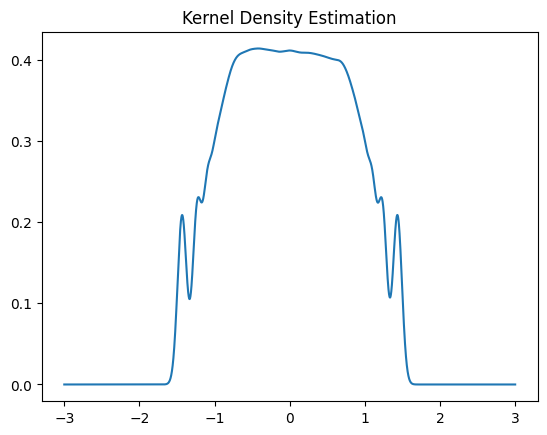

In [8]:
from matplotlib import pyplot as plt
from sklearn.neighbors import KernelDensity

state = 4
bandwidth = 0.06

for action in range(params.action_size):
    action_quantiles = tables[-1, state, action]
    samples = action_quantiles[:, None]
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(samples)
    
    x_grid = np.linspace(-3, 3, 10_000)[:, None]
    log_pdf = kde.score_samples(x_grid)
    pdf = np.exp(log_pdf)

    plt.plot(x_grid[:,0], pdf)
    plt.title("Kernel Density Estimation")
    plt.show()